In [1]:
import numpy
import pandas as pd
from geopy.distance import geodesic

In [2]:
fraud_test_df = pd.read_csv("../datas/fraudTest.csv")
fraud_train_df = pd.read_csv("../datas/fraudTrain.csv")

In [3]:
fraud_train_df.sample(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
460823,460823,2019-07-22 13:37:57,376445266762684,"fraud_Schneider, Hayes and Nikolaus",food_dining,8.12,Rachel,Lowe,F,372 Jeffrey Course,...,41.1558,-101.1360,1789,Insurance broker,1982-02-11,239a783f037cd651df2587fc79f49f84,1342964277,41.755823,-101.732194,0
685751,685751,2019-10-19 21:59:31,4457732997086323466,"fraud_Champlin, Rolfson and Connelly",travel,507.14,Stanley,Mayo,M,3433 Jones Branch,...,38.5234,-120.6763,832,Immigration officer,1987-05-19,257a5e29bfec8c8574f35a6a07036fb4,1350683971,39.167400,-120.868028,0
805475,805475,2019-12-05 19:57:16,4239436242473,"fraud_Bernhard, Grant and Langworth",shopping_pos,1.84,James,Leon,M,826 Benjamin Stravenue,...,38.8320,-77.1200,321490,"Scientist, biomedical",1991-10-04,0998653f6fc2a12c7ad9ba9b1e15d8d8,1354737436,39.691316,-76.659999,0
681688,681688,2019-10-18 03:06:05,2657850734909997,fraud_Pouros-Conroy,shopping_pos,510.29,Alan,Howard,M,04139 Johnson Prairie Suite 401,...,42.3749,-83.1087,673342,Trading standards officer,1946-11-01,6284075eb24ca2428a5f028d65cc4ad8,1350529565,43.285479,-83.159065,0
1030470,1030470,2020-03-02 22:40:59,376944481517097,"fraud_Casper, Hand and Zulauf",grocery_pos,303.13,Tiffany,Stephens,F,1447 Ryan Lodge,...,30.4983,-88.3282,15647,"Scientist, physiological",1957-12-26,ee95f1d93d5c95862639973447facbe5,1362264059,30.387532,-88.133421,1


In [4]:
fraud_train_df.shape

(1296675, 23)

In [5]:
fraud_train_df["is_fraud"].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [6]:
fraud_test_df.isna().sum() / len(fraud_test_df) * 100

Unnamed: 0               0.0
trans_date_trans_time    0.0
cc_num                   0.0
merchant                 0.0
category                 0.0
amt                      0.0
first                    0.0
last                     0.0
gender                   0.0
street                   0.0
city                     0.0
state                    0.0
zip                      0.0
lat                      0.0
long                     0.0
city_pop                 0.0
job                      0.0
dob                      0.0
trans_num                0.0
unix_time                0.0
merch_lat                0.0
merch_long               0.0
is_fraud                 0.0
dtype: float64

In [7]:
fraud_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [8]:
fraud_train_df["category"].value_counts()

category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
misc_pos           79655
misc_net           63287
grocery_net        45452
travel             40507
Name: count, dtype: int64

In [9]:
fraud_test_df["job"].value_counts()

job
Film/video editor                4119
Exhibition designer              3968
Surveyor, land/geomatics         3756
Naval architect                  3750
Designer, ceramics/pottery       3463
                                 ... 
Estate manager/land agent         195
Engineer, civil (consulting)      194
Operational investment banker      11
Software engineer                  11
Engineer, water                     8
Name: count, Length: 478, dtype: int64

In [10]:
fraud_train_df["cc_num"].value_counts()

cc_num
571365235126           3123
4512828414983801773    3123
36722699017270         3119
213112402583773        3117
3545109339866548       3113
                       ... 
180097223252063           7
4225628813173670          7
501894933032              7
4975457191020             7
340187018810220           7
Name: count, Length: 983, dtype: int64

In [11]:
fraud_train_df["state"].value_counts()

state
TX    94876
NY    83501
PA    79847
CA    56360
OH    46480
MI    46154
IL    43252
FL    42671
AL    40989
MO    38403
MN    31714
AR    31127
NC    30266
WI    29368
VA    29250
SC    29190
KY    28475
IN    27580
IA    26985
OK    26671
MD    26193
GA    26063
WV    25691
NJ    24603
NE    24168
KS    22996
MS    21188
LA    20965
WY    19322
WA    18924
OR    18597
TN    17554
ME    16505
NM    16407
ND    14786
CO    13880
MA    12376
SD    12324
VT    11768
MT    11754
AZ    10770
UT    10699
NH     8278
CT     7702
NV     5607
ID     5545
DC     3613
HI     2559
AK     2120
RI      550
DE        9
Name: count, dtype: int64

In [12]:
#drop colonnes innutiles
drop_cols = ["Unnamed: 0", "cc_num", "merchant", "first", "last", "street", "zip", "unix_time", "trans_num", "city"]
df_clean = fraud_train_df.drop(columns=drop_cols)

#age du consommateur
df_clean["dob"] = pd.to_datetime(df_clean["dob"])
df_clean["age"] = pd.Timestamp.now().year - df_clean["dob"].dt.year

df_clean = df_clean.drop(columns=["dob"])

#nombre de KM entre vendeur et consommateur
df_clean["distance_km"] = df_clean.apply(
    lambda row: int(geodesic(
        (row["lat"], row["long"]), 
        (row["merch_lat"], row["merch_long"])
    ).km), axis=1
)

drop_loc_cols = ["lat", "long", "merch_lat", "merch_long"]
df_clean = df_clean.drop(columns=drop_loc_cols)


In [13]:
df_clean["trans_date_trans_time"] = pd.to_datetime(df_clean["trans_date_trans_time"])

df_clean["hour"]  = df_clean["trans_date_trans_time"].dt.hour
df_clean["day"]   = df_clean["trans_date_trans_time"].dt.day
df_clean["month"] = df_clean["trans_date_trans_time"].dt.month
df_clean["year"]  = df_clean["trans_date_trans_time"].dt.year

df_clean = df_clean.drop(columns=["trans_date_trans_time"])

In [14]:
df_clean.head()

,category,amt,gender,state,city_pop,job,is_fraud,age,distance_km,hour,day,month,year
0,misc_net,4.97,F,NC,3495,"Psychologist, counselling",0,38,78,0,1,1,2019
1,grocery_pos,107.23,F,WA,149,Special educational needs teacher,0,48,30,0,1,1,2019
2,entertainment,220.11,M,ID,4154,Nature conservation officer,0,64,108,0,1,1,2019
3,gas_transport,45.00,M,MT,1939,Patent attorney,0,59,95,0,1,1,2019
4,misc_pos,41.96,M,VA,99,Dance movement psychotherapist,0,40,77,0,1,1,2019


In [15]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 13 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   category     1296675 non-null  object 
 1   amt          1296675 non-null  float64
 2   gender       1296675 non-null  object 
 3   state        1296675 non-null  object 
 4   city_pop     1296675 non-null  int64  
 5   job          1296675 non-null  object 
 6   is_fraud     1296675 non-null  int64  
 7   age          1296675 non-null  int64  
 8   distance_km  1296675 non-null  int64  
 9   hour         1296675 non-null  int32  
 10  day          1296675 non-null  int32  
 11  month        1296675 non-null  int32  
 12  year         1296675 non-null  int32  
dtypes: float64(1), int32(4), int64(4), object(4)
memory usage: 108.8+ MB


In [16]:
df_clean["job"].unique()

array(['Psychologist, counselling', 'Special educational needs teacher',
       'Nature conservation officer', 'Patent attorney',
       'Dance movement psychotherapist', 'Transport planner',
       'Arboriculturist', 'Designer, multimedia',
       'Public affairs consultant', 'Pathologist', 'IT trainer',
       'Systems developer', 'Engineer, land', 'Systems analyst',
       'Naval architect', 'Radiographer, diagnostic',
       'Programme researcher, broadcasting/film/video', 'Energy engineer',
       'Event organiser', 'Operational researcher', 'Market researcher',
       'Probation officer', 'Leisure centre manager',
       'Corporate investment banker', 'Therapist, occupational',
       'Call centre manager', 'Police officer',
       'Education officer, museum', 'Physiotherapist', 'Network engineer',
       'Forensic psychologist', 'Geochemist',
       'Armed forces training and education officer',
       'Designer, furniture', 'Optician, dispensing',
       'Psychologist, forensic

In [17]:
df_clean["job"].nunique()

494

In [18]:
def categorize_job(job):
    job = job.lower()
    if any(w in job for w in ["engineer", "developer", "data", "software", "tech", "it", "programmer", "web", "seismic", "geophysic", "statistician", "cartographer"]):
        return "tech"
    elif any(w in job for w in ["health", "ambulance" "doctor", "nurse", "surgeon", "therapist", "medical", "paramedic", "radiograph", "optometrist", "chiropodist", "audiolog", "oncologist", "osteopath", "podiatrist", "pathologist", "immunologist", "physiologist", "toxicologist", "embryologist", "biochemist", "pharmacolog", "psychiatrist", "psychologist", "counsell", "optician", "herbalist", "acupuncturist", "orthoptist", "occupational hygienist", "clinical"]):
        return "health"
    elif any(w in job for w in ["teacher", "professor", "lecturer", "educator", "tutor", "librarian", "archivist", "education", "mentor", "learning"]):
        return "education"
    elif any(w in job for w in ["manager", "director", "officer", "executive", "ceo", "administrator", "coordinator", "comptroller", "company secretary", "chief of staff"]):
        return "management"
    elif any(w in job for w in ["accountant", "financial", "banker", "analyst", "tax", "insurance", "broker", "pensions", "economist", "futures trader", "dealer", "claims inspector", "loss adjuster"]):
        return "finance"
    elif any(w in job for w in ["driver", "delivery", "transport", "pilot", "freight", "air broker", "cabin crew", "air cabin"]):
        return "transport"
    elif any(w in job for w in ["designer", "artist", "musician", "journalist", "media", "broadcast", "photographer", "ceramics", "jewellery", "animator", "illustrator", "producer", "radio producer", "camera operator", "gaffer", "television", "curator", "conservator"]):
        return "creative"
    elif any(w in job for w in ["lawyer", "barrister", "legal", "conveyancer", "loss adjuster", "attorney", "patent", "trade mark"]):
        return "legal"
    elif any(w in job for w in ["scientist", "researcher", "geologist", "ecologist", "geneticist", "geochemist", "hydrogeologist", "archaeologist", "oceanographer", "hydrologist", "chemist", "metallurgist", "mudlogger"]):
        return "science"
    elif any(w in job for w in ["surveyor", "planner", "architect", "contractor", "building", "land"]):
        return "construction"
    elif any(w in job for w in ["consultant", "adviser", "advisor"]):
        return "consulting"
    elif any(w in job for w in ["firefighter", "police", "security", "military", "warden", "ranger"]):
        return "public_safety"
    elif any(w in job for w in ["farmer", "agricultural", "horticulturist", "arboriculturist"]):
        return "agriculture"
    elif any(w in job for w in ["buyer", "merchandiser", "retail", "bookseller", "barista", "dealer"]):
        return "commerce"
    elif any(w in job for w in ["aid worker", "development worker", "volunteer", "charity"]):
        return "social"
    elif any(w in job for w in ["sport", "exercise", "fitness"]):
        return "sport"
    else:
        return "other"


df_clean["customer_job_category"] = df_clean["job"].apply(categorize_job)
df_clean = df_clean.drop(columns=["job"])

In [19]:
df_clean["customer_job_category"].nunique()

16

In [20]:
df_clean["customer_job_category"].unique()

array(['health', 'education', 'management', 'legal', 'transport',
       'agriculture', 'creative', 'consulting', 'tech', 'finance',
       'other', 'science', 'construction', 'commerce', 'social',
       'public_safety'], dtype=object)

In [21]:
df_clean["customer_job_category"].value_counts()

customer_job_category
tech             378778
health           220187
management       163508
creative         106292
finance           89113
education         82286
science           76376
construction      53712
other             37014
legal             20455
consulting        18292
commerce          15953
transport         12806
public_safety      8649
agriculture        8185
social             5069
Name: count, dtype: int64

In [22]:
df_clean["category"].value_counts()

category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
misc_pos           79655
misc_net           63287
grocery_net        45452
travel             40507
Name: count, dtype: int64

In [23]:
df_clean.sample(25)

,category,amt,gender,state,city_pop,is_fraud,age,distance_km,hour,day,month,year,customer_job_category
1049602,health_fitness,60.59,M,AR,2501,0,40,100,22,10,3,2020,finance
229704,gas_transport,60.60,M,NM,899,0,59,101,11,26,4,2019,tech
641185,health_fitness,62.49,F,AZ,2872,0,39,92,21,29,9,2019,tech
418535,health_fitness,26.57,M,CA,172817,0,44,102,18,7,7,2019,construction
1011363,shopping_net,1.96,F,CA,92043,0,65,53,0,21,2,2020,tech
26107,kids_pets,2.99,M,GA,1461,0,91,55,20,15,1,2019,tech
1052290,personal_care,205.71,F,CO,320420,0,51,120,15,12,3,2020,tech
64505,entertainment,37.38,F,DC,601723,0,40,71,21,7,2,2019,management
983775,health_fitness,14.50,M,AR,111,0,26,73,23,3,2,2020,management
93771,grocery_pos,122.86,F,WA,149,0,48,83,3,25,2,2019,education


In [24]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 13 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   category               1296675 non-null  object 
 1   amt                    1296675 non-null  float64
 2   gender                 1296675 non-null  object 
 3   state                  1296675 non-null  object 
 4   city_pop               1296675 non-null  int64  
 5   is_fraud               1296675 non-null  int64  
 6   age                    1296675 non-null  int64  
 7   distance_km            1296675 non-null  int64  
 8   hour                   1296675 non-null  int32  
 9   day                    1296675 non-null  int32  
 10  month                  1296675 non-null  int32  
 11  year                   1296675 non-null  int32  
 12  customer_job_category  1296675 non-null  object 
dtypes: float64(1), int32(4), int64(4), object(4)
memory usage: 108.8+ MB


# Exploration Visuelle des Données

Analyse des patterns de fraude sur le dataset d'entraînement.

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
FRAUD_COLOR    = "#e74c3c"
NOFRAUD_COLOR  = "#3498db"

## 1. Déséquilibre des classes

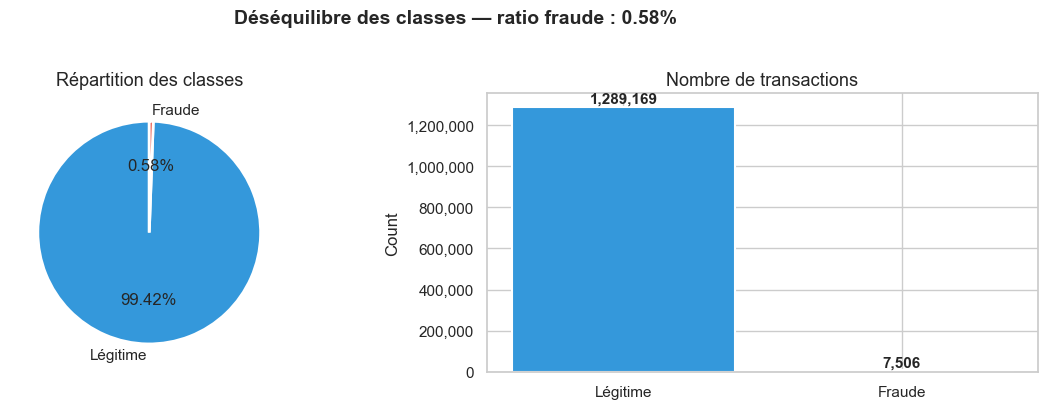

In [26]:
counts = df_clean["is_fraud"].value_counts()
labels = ["Légitime", "Fraude"]
colors = [NOFRAUD_COLOR, FRAUD_COLOR]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
axes[0].pie(counts, labels=labels, colors=colors, autopct="%1.2f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Répartition des classes", fontsize=13)

# Bar chart avec les valeurs exactes
bars = axes[1].bar(labels, counts.values, color=colors, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
                 f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[1].set_title("Nombre de transactions", fontsize=13)
axes[1].set_ylabel("Count")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle(f"Déséquilibre des classes — ratio fraude : {counts[1]/counts.sum()*100:.2f}%",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 2. Taux de fraude par catégorie de marchand

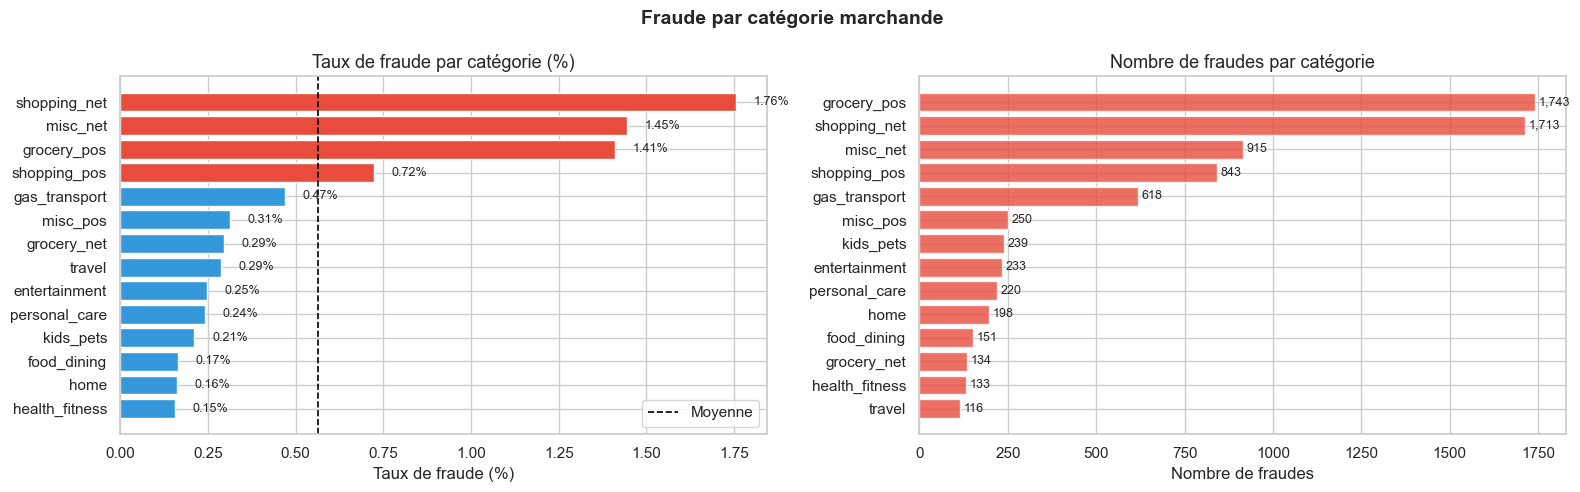

In [27]:
fraud_by_cat = (
    df_clean.groupby("category")["is_fraud"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "nb_fraudes", "count": "nb_total"})
    .assign(taux_fraude=lambda x: x["nb_fraudes"] / x["nb_total"] * 100)
    .sort_values("taux_fraude", ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Taux de fraude (%)
colors = [FRAUD_COLOR if t > fraud_by_cat["taux_fraude"].mean() else NOFRAUD_COLOR
          for t in fraud_by_cat["taux_fraude"]]
bars = axes[0].barh(fraud_by_cat.index, fraud_by_cat["taux_fraude"], color=colors)
axes[0].axvline(fraud_by_cat["taux_fraude"].mean(), color="black", linestyle="--", linewidth=1.2, label="Moyenne")
for bar, val in zip(bars, fraud_by_cat["taux_fraude"]):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                 f"{val:.2f}%", va="center", fontsize=9)
axes[0].set_title("Taux de fraude par catégorie (%)", fontsize=13)
axes[0].set_xlabel("Taux de fraude (%)")
axes[0].legend()

# Volume de fraudes
fraud_by_cat_sorted = fraud_by_cat.sort_values("nb_fraudes", ascending=True)
axes[1].barh(fraud_by_cat_sorted.index, fraud_by_cat_sorted["nb_fraudes"], color=FRAUD_COLOR, alpha=0.8)
for i, (val, total) in enumerate(zip(fraud_by_cat_sorted["nb_fraudes"], fraud_by_cat_sorted["nb_total"])):
    axes[1].text(val + 10, i, f"{val:,}", va="center", fontsize=9)
axes[1].set_title("Nombre de fraudes par catégorie", fontsize=13)
axes[1].set_xlabel("Nombre de fraudes")

plt.suptitle("Fraude par catégorie marchande", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Distribution des montants — Fraude vs Légitime

Médiane fraude   : $396.50
Médiane légitime : $47.28
Moyenne fraude   : $531.32
Moyenne légitime : $67.67


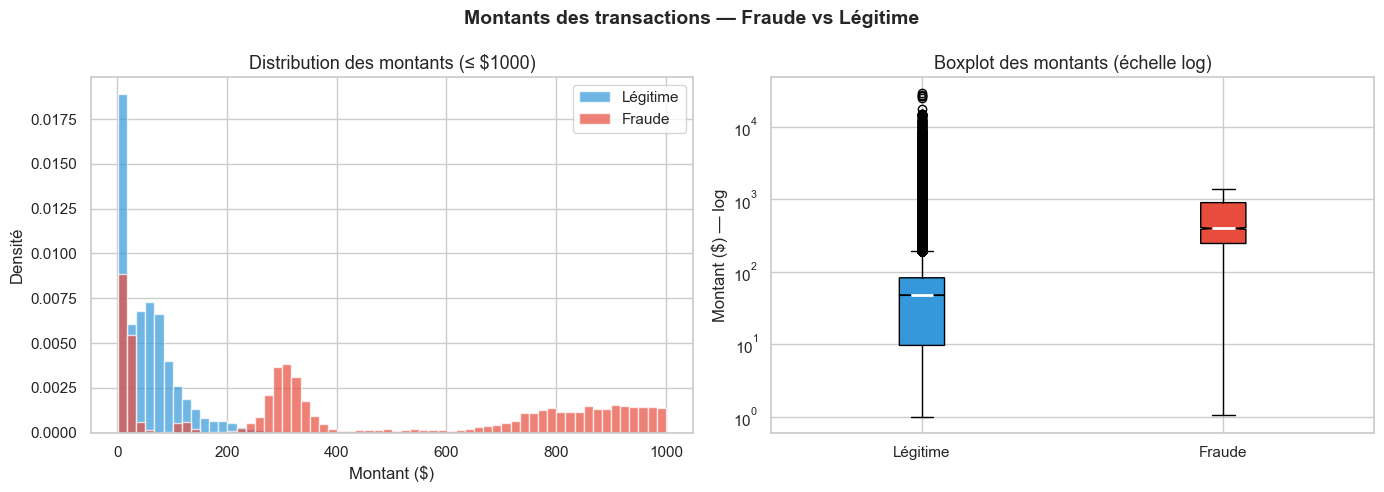

In [28]:
fraud    = df_clean[df_clean["is_fraud"] == 1]["amt"]
legit    = df_clean[df_clean["is_fraud"] == 0]["amt"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme (cap à 1000$ pour la lisibilité)
cap = 1000
axes[0].hist(legit[legit <= cap], bins=60, color=NOFRAUD_COLOR, alpha=0.7, label="Légitime", density=True)
axes[0].hist(fraud[fraud <= cap], bins=60, color=FRAUD_COLOR,   alpha=0.7, label="Fraude",   density=True)
axes[0].set_title(f"Distribution des montants (≤ ${cap})", fontsize=13)
axes[0].set_xlabel("Montant ($)")
axes[0].set_ylabel("Densité")
axes[0].legend()

# Boxplot comparatif (log scale)
data_box = [legit, fraud]
bp = axes[1].boxplot(data_box, patch_artist=True, notch=True,
                     medianprops={"color": "white", "linewidth": 2})
bp["boxes"][0].set_facecolor(NOFRAUD_COLOR)
bp["boxes"][1].set_facecolor(FRAUD_COLOR)
axes[1].set_yscale("log")
axes[1].set_xticks([1, 2])
axes[1].set_xticklabels(["Légitime", "Fraude"])
axes[1].set_title("Boxplot des montants (échelle log)", fontsize=13)
axes[1].set_ylabel("Montant ($) — log")

medians = [fraud.median(), legit.median()]
print(f"Médiane fraude   : ${fraud.median():.2f}")
print(f"Médiane légitime : ${legit.median():.2f}")
print(f"Moyenne fraude   : ${fraud.mean():.2f}")
print(f"Moyenne légitime : ${legit.mean():.2f}")

plt.suptitle("Montants des transactions — Fraude vs Légitime", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Fraude par heure de la journée

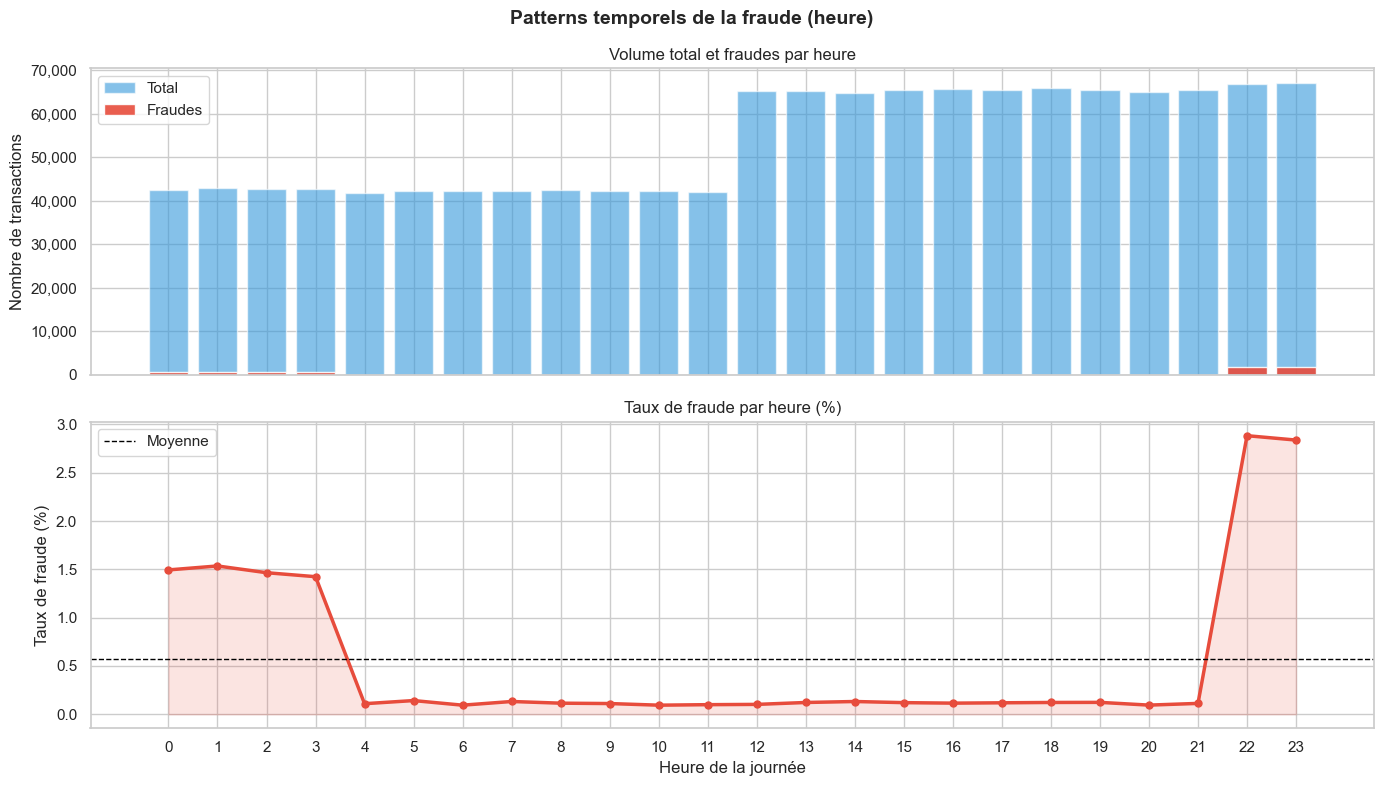

In [29]:
hourly = (
    df_clean.groupby("hour")["is_fraud"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "fraudes", "count": "total"})
    .assign(taux=lambda x: x["fraudes"] / x["total"] * 100)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Volume total vs fraudes
axes[0].bar(hourly.index, hourly["total"],   color=NOFRAUD_COLOR, alpha=0.6, label="Total")
axes[0].bar(hourly.index, hourly["fraudes"], color=FRAUD_COLOR,   alpha=0.9, label="Fraudes")
axes[0].set_ylabel("Nombre de transactions")
axes[0].set_title("Volume total et fraudes par heure", fontsize=12)
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Taux de fraude
axes[1].plot(hourly.index, hourly["taux"], color=FRAUD_COLOR, linewidth=2.5, marker="o", markersize=5)
axes[1].fill_between(hourly.index, hourly["taux"], alpha=0.15, color=FRAUD_COLOR)
axes[1].axhline(hourly["taux"].mean(), color="black", linestyle="--", linewidth=1, label="Moyenne")
axes[1].set_xlabel("Heure de la journée")
axes[1].set_ylabel("Taux de fraude (%)")
axes[1].set_title("Taux de fraude par heure (%)", fontsize=12)
axes[1].set_xticks(range(24))
axes[1].legend()

plt.suptitle("Patterns temporels de la fraude (heure)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Fraude par tranche d'âge

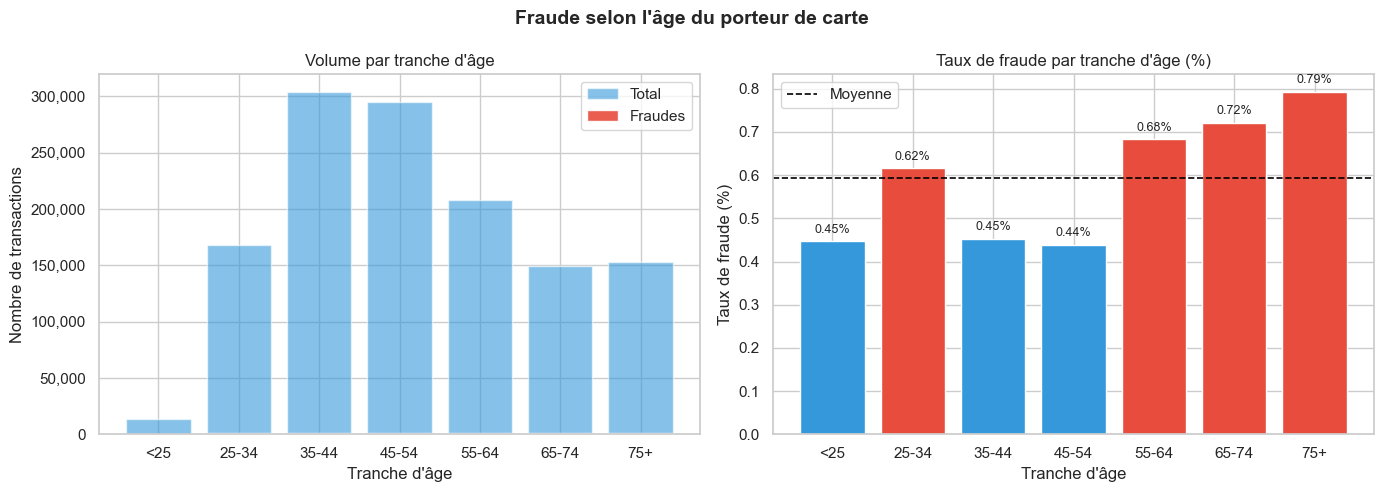

In [30]:
bins   = [0, 25, 35, 45, 55, 65, 75, 100]
labels_age = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", "75+"]
df_clean["age_group"] = pd.cut(df_clean["age"], bins=bins, labels=labels_age, right=False)

age_stats = (
    df_clean.groupby("age_group", observed=True)["is_fraud"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "fraudes", "count": "total"})
    .assign(taux=lambda x: x["fraudes"] / x["total"] * 100)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volume
x = range(len(age_stats))
axes[0].bar(x, age_stats["total"],   color=NOFRAUD_COLOR, alpha=0.6, label="Total")
axes[0].bar(x, age_stats["fraudes"], color=FRAUD_COLOR,   alpha=0.9, label="Fraudes")
axes[0].set_xticks(x)
axes[0].set_xticklabels(age_stats.index)
axes[0].set_title("Volume par tranche d'âge", fontsize=12)
axes[0].set_xlabel("Tranche d'âge")
axes[0].set_ylabel("Nombre de transactions")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].legend()

# Taux
bar_colors = [FRAUD_COLOR if t > age_stats["taux"].mean() else NOFRAUD_COLOR for t in age_stats["taux"]]
bars = axes[1].bar(x, age_stats["taux"], color=bar_colors)
axes[1].axhline(age_stats["taux"].mean(), color="black", linestyle="--", linewidth=1.2, label="Moyenne")
axes[1].set_xticks(x)
axes[1].set_xticklabels(age_stats.index)
for bar, val in zip(bars, age_stats["taux"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f"{val:.2f}%", ha="center", fontsize=9)
axes[1].set_title("Taux de fraude par tranche d'âge (%)", fontsize=12)
axes[1].set_xlabel("Tranche d'âge")
axes[1].set_ylabel("Taux de fraude (%)")
axes[1].legend()

plt.suptitle("Fraude selon l'âge du porteur de carte", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Distance marchand / porteur de carte et fraude

Distance médiane fraude   : 78 km
Distance médiane légitime : 78 km


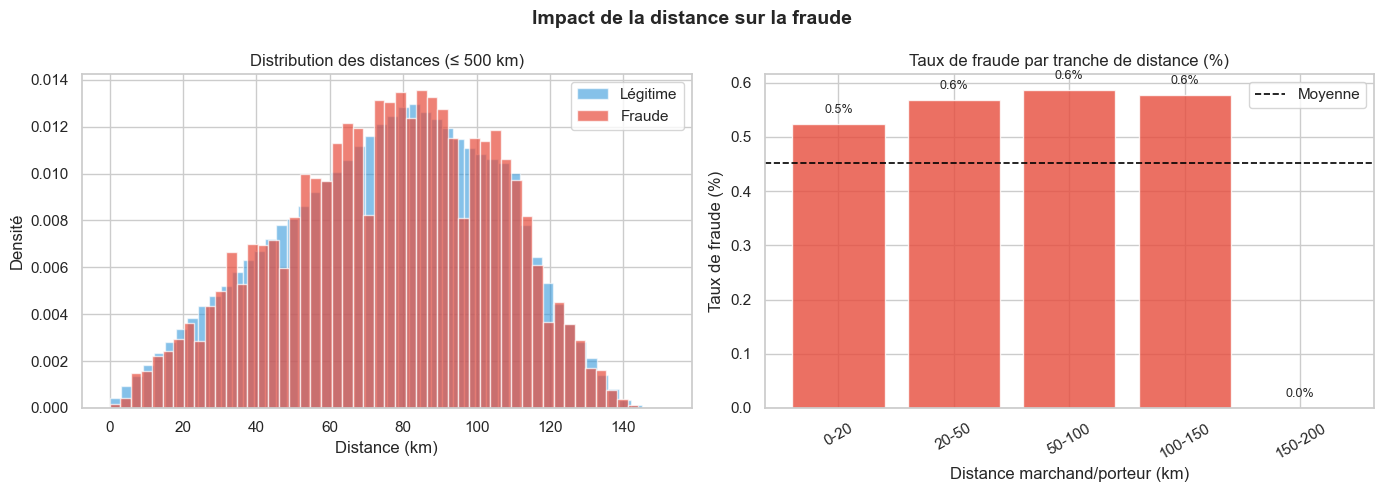

In [31]:
dist_fraud = df_clean[df_clean["is_fraud"] == 1]["distance_km"]
dist_legit = df_clean[df_clean["is_fraud"] == 0]["distance_km"]

dist_bins = [0, 20, 50, 100, 150, 200, 300, 500, 5000]
dist_labels = ["0-20", "20-50", "50-100", "100-150", "150-200", "200-300", "300-500", "500+"]
df_clean["dist_group"] = pd.cut(df_clean["distance_km"], bins=dist_bins, labels=dist_labels, right=False)

dist_stats = (
    df_clean.groupby("dist_group", observed=True)["is_fraud"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "fraudes", "count": "total"})
    .assign(taux=lambda x: x["fraudes"] / x["total"] * 100)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot
axes[0].hist(dist_legit[dist_legit <= 500], bins=50, density=True, color=NOFRAUD_COLOR, alpha=0.6, label="Légitime")
axes[0].hist(dist_fraud[dist_fraud <= 500], bins=50, density=True, color=FRAUD_COLOR,   alpha=0.7, label="Fraude")
axes[0].set_title("Distribution des distances (≤ 500 km)", fontsize=12)
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Densité")
axes[0].legend()
print(f"Distance médiane fraude   : {dist_fraud.median():.0f} km")
print(f"Distance médiane légitime : {dist_legit.median():.0f} km")

# Taux par tranche de distance
x = range(len(dist_stats))
bars = axes[1].bar(x, dist_stats["taux"], color=FRAUD_COLOR, alpha=0.8)
axes[1].axhline(dist_stats["taux"].mean(), color="black", linestyle="--", linewidth=1.2, label="Moyenne")
axes[1].set_xticks(x)
axes[1].set_xticklabels(dist_stats.index, rotation=30)
for bar, val in zip(bars, dist_stats["taux"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                 f"{val:.1f}%", ha="center", fontsize=9)
axes[1].set_title("Taux de fraude par tranche de distance (%)", fontsize=12)
axes[1].set_xlabel("Distance marchand/porteur (km)")
axes[1].set_ylabel("Taux de fraude (%)")
axes[1].legend()

plt.suptitle("Impact de la distance sur la fraude", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Fraude par genre et catégorie de métier

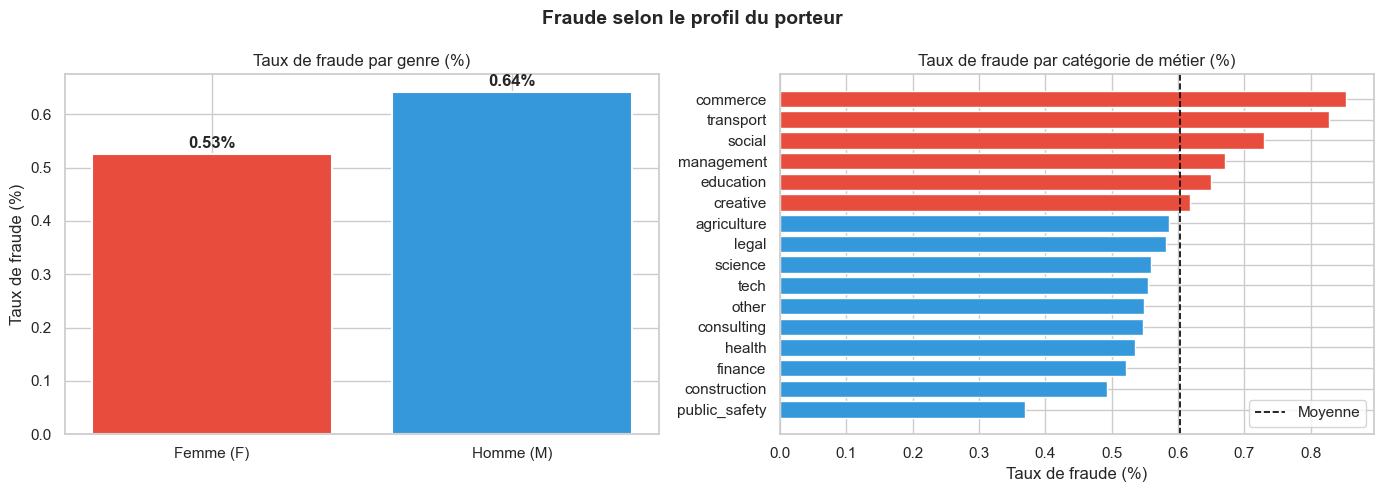

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Genre
gender_stats = (
    df_clean.groupby("gender")["is_fraud"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "fraudes", "count": "total"})
    .assign(taux=lambda x: x["fraudes"] / x["total"] * 100)
)
bars = axes[0].bar(["Femme (F)", "Homme (M)"], gender_stats["taux"],
                   color=[FRAUD_COLOR, NOFRAUD_COLOR], edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, gender_stats["taux"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.2f}%", ha="center", fontsize=12, fontweight="bold")
axes[0].set_title("Taux de fraude par genre (%)", fontsize=12)
axes[0].set_ylabel("Taux de fraude (%)")

# Catégorie de métier
job_stats = (
    df_clean.groupby("customer_job_category")["is_fraud"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "fraudes", "count": "total"})
    .assign(taux=lambda x: x["fraudes"] / x["total"] * 100)
    .sort_values("taux", ascending=True)
)
bar_colors = [FRAUD_COLOR if t > job_stats["taux"].mean() else NOFRAUD_COLOR for t in job_stats["taux"]]
axes[1].barh(job_stats.index, job_stats["taux"], color=bar_colors)
axes[1].axvline(job_stats["taux"].mean(), color="black", linestyle="--", linewidth=1.2, label="Moyenne")
axes[1].set_title("Taux de fraude par catégorie de métier (%)", fontsize=12)
axes[1].set_xlabel("Taux de fraude (%)")
axes[1].legend()

plt.suptitle("Fraude selon le profil du porteur", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Matrice de corrélation (variables numériques)

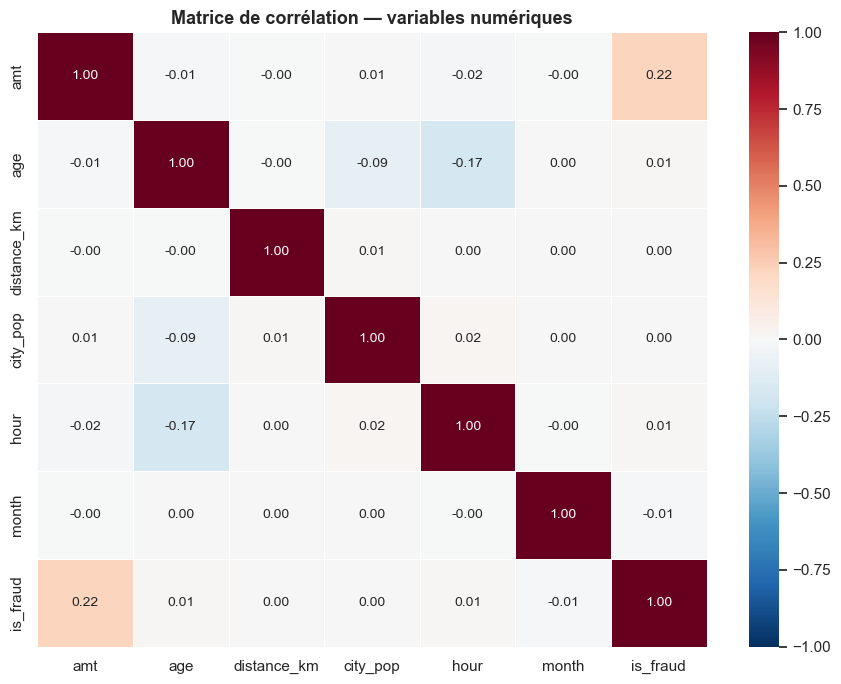


Corrélations avec is_fraud (triées) :
amt            0.219404
hour           0.013799
month         -0.012409
age            0.012378
city_pop       0.002136
distance_km    0.000404


In [33]:
num_cols = ["amt", "age", "distance_km", "city_pop", "hour", "month", "is_fraud"]
corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = corr.abs() < 0.01  # masque les corrélations quasi nulles
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    annot_kws={"size": 10},
)
ax.set_title("Matrice de corrélation — variables numériques", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Top corrélations avec is_fraud
print("\nCorrélations avec is_fraud (triées) :")
print(corr["is_fraud"].drop("is_fraud").sort_values(key=abs, ascending=False).to_string())